# Negative controls

В предыдущих ноутбуках `GRU mean pooling` показал полезность в оценке удержания. Здесь проверяем, насколько этот результат устойчив к простым контрольным представлениям.

Главный вопрос ноутбука: RNN-эмбеддинги действительно несут поведенческий сигнал или качество можно объяснить случайной размерностью, частотами событий или слабой ролью порядка?

## План

1. Загрузить тот же `prefix_len=150` retention protocol, что в ablation способа pooling.
2. Построить референсные `GRU mean`-эмбеддинги.
3. Построить три negative controls: `Random embeddings`, `Bag-of-events`, `Shuffled GRU mean`.
4. Оценить все варианты через одинаковый XGBoost downstream evaluation.
5. Сравнить test ROC-AUC / PR-AUC и сформулировать выводы.

In [1]:
from collections import Counter
from pathlib import Path
import json
import os
import sys

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '8')

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns
import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.controls import build_bag_of_events_features, build_random_embeddings, shuffle_user_prefixes
from src.data import load_prepared_sequences
from src.downstream import build_base_meta, build_baseline_features, build_meta_for_prefix, evaluate_xgboost_feature_set
from src.embedding_analysis import embedding_columns
from src.models import GRUEncoder
from src.pooling import build_user_embeddings_with_pooling
from src.splits import apply_user_split, load_user_split
from src.train import choose_device, seed_everything

sns.set_theme(style='whitegrid', context='notebook')
pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_cols(20)

def to_pandas(df: pl.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(df.to_dicts())

DATA_DIR = PROJECT_ROOT / 'artifacts/data'
RNN_DIR = PROJECT_ROOT / 'artifacts/rnn'
OUT_DIR = PROJECT_ROOT / 'artifacts/negative_controls'
FIGURES_DIR = OUT_DIR / 'figures'
EMBEDDINGS_DIR = OUT_DIR / 'embeddings'
for path in [OUT_DIR, FIGURES_DIR, EMBEDDINGS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
PREFIX_LEN = 150
TOP_K_EVENTS = 10
HORIZONS = {'retention_7d': 7, 'retention_14d': 14}
POOLING = 'mean'
BATCH_SIZE = 512

seed_everything(SEED)
device = choose_device()
print(f'device={device}, prefix_len={PREFIX_LEN}, pooling={POOLING}')

device=mps, prefix_len=150, pooling=mean


## 1. Данные и модель

Используем уже подготовленные последовательности, фиксированный user-level split и метки из честного prefix-based протокола. В качестве энкодера берём сохранённый `GRU`, обученный на next-event prediction.

In [2]:
prepared = load_prepared_sequences(DATA_DIR)
split = load_user_split(DATA_DIR / 'split.json')
split_prepared = apply_user_split(prepared, split)
train_prepared = split_prepared['train']
split_users_df = pl.read_parquet(DATA_DIR / 'split_users.parquet')

base_meta_df, data_end_ts = build_base_meta(str(DATA_DIR / 'clean_events' / '*.parquet'), prepared.user_ids)
meta_df, label_summary_df = build_meta_for_prefix(
    base_meta_df,
    prefix_len=PREFIX_LEN,
    horizons=HORIZONS,
    data_end_ts=data_end_ts,
)

config = json.loads((RNN_DIR / 'rnn_config.json').read_text(encoding='utf-8'))
checkpoint = torch.load(RNN_DIR / 'rnn_encoder.pt', map_location='cpu')
model = GRUEncoder(
    vocab_size=len(prepared.event2idx),
    event_dim=config['event_dim'],
    hidden_dim=config['hidden_dim'],
    num_layers=config['num_layers'],
    dropout=config['dropout'],
).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

label_summary_df

prefix_len,label,valid_users,positive_rate
i64,str,i64,f64
150,"""retention_7d""",18547,0.281124
150,"""retention_14d""",15207,0.181758


Вывод.

Negative controls используют тот же `prefix_len=150`, тот же split и те же retention labels, что ablation способа pooling. Это важно: если контроль выигрывает или почти не уступает RNN, причина не в другом датасете, а в свойствах самого представления.


## 2. Baseline

Собираем табличными baseline-признаками из длины префикса, числа уникальных событий, repeat ratio, активности по сессиям/дням и долей top-10 событий. Эти признаки нужны как референсный и как часть комбинированных наборы признаков.

In [3]:
baseline_df, baseline_feature_cols, baseline_summary_df = build_baseline_features(
    prepared,
    train_prepared,
    split_users_df,
    meta_df,
    prefix_len=PREFIX_LEN,
    top_k_events=TOP_K_EVENTS,
    horizons=HORIZONS,
)

train_prefix_counter = Counter()
for seq in train_prepared.user_sequences:
    train_prefix_counter.update(seq[:PREFIX_LEN])
top_event_ids = [event_id for event_id, _ in train_prefix_counter.most_common(TOP_K_EVENTS)]

baseline_summary_df

prefix_len,feature_group,num_features,top_events_used
i64,str,i64,str
150,"""baseline""",15,"""REWARD, machine_learning, Trai…"


## 3. Контрольные представления

Строим четыре эмбеддинг/feature варианта на одном и том же `prefix_len=150`:

- `GRU mean`: обычный RNN-эмбеддинг с сохранением порядка событий;
- `Random embeddings`: случайные признаки той же размерности, что и GRU эмбеддинг;
- `Bag-of-events`: доли top-10 событий без информации о порядке;
- `Shuffled GRU mean`: тот же GRU-энкодер, но порядок событий перемешан только внутри первых 150 событий пользователя.

In [4]:
gru_mean_df = build_user_embeddings_with_pooling(
    model,
    prepared,
    max_len=PREFIX_LEN,
    batch_size=BATCH_SIZE,
    device=device,
    pooling=POOLING,
    take_last=False,
).join(split_users_df, on='appmetrica_device_id', how='inner')
gru_mean_cols = embedding_columns(gru_mean_df.columns)
gru_mean_df.write_parquet(EMBEDDINGS_DIR / 'gru_mean.parquet')

random_df = build_random_embeddings(
    prepared.user_ids,
    embedding_dim=len(gru_mean_cols),
    seed=SEED,
).join(split_users_df, on='appmetrica_device_id', how='inner')
random_cols = embedding_columns(random_df.columns)
random_df.write_parquet(EMBEDDINGS_DIR / 'random_embeddings.parquet')

bag_df, bag_cols = build_bag_of_events_features(
    prepared,
    event_ids=top_event_ids,
    prefix_len=PREFIX_LEN,
)
bag_df = bag_df.join(baseline_df.select(['appmetrica_device_id', *HORIZONS.keys(), 'split']), on='appmetrica_device_id', how='inner')
bag_df.write_parquet(EMBEDDINGS_DIR / 'bag_of_events_features.parquet')

shuffled_prepared = shuffle_user_prefixes(prepared, prefix_len=PREFIX_LEN, seed=SEED)
shuffled_gru_df = build_user_embeddings_with_pooling(
    model,
    shuffled_prepared,
    max_len=PREFIX_LEN,
    batch_size=BATCH_SIZE,
    device=device,
    pooling=POOLING,
    take_last=False,
).join(split_users_df, on='appmetrica_device_id', how='inner')
shuffled_cols = embedding_columns(shuffled_gru_df.columns)
shuffled_gru_df.write_parquet(EMBEDDINGS_DIR / 'shuffled_gru_mean.parquet')

representation_summary_df = pl.DataFrame([
    {'representation': 'Baseline tabular', 'num_features': len(baseline_feature_cols), 'num_users': baseline_df.height},
    {'representation': 'GRU mean', 'num_features': len(gru_mean_cols), 'num_users': gru_mean_df.height},
    {'representation': 'Random embeddings', 'num_features': len(random_cols), 'num_users': random_df.height},
    {'representation': 'Bag-of-events', 'num_features': len(bag_cols), 'num_users': bag_df.height},
    {'representation': 'Shuffled GRU mean', 'num_features': len(shuffled_cols), 'num_users': shuffled_gru_df.height},
])
representation_summary_df.write_csv(OUT_DIR / 'negative_control_representations.csv')
representation_summary_df

representation,num_features,num_users
str,i64,i64
"""Baseline tabular""",15,52495
"""GRU mean""",128,52495
"""Random embeddings""",128,52495
"""Bag-of-events""",10,52495
"""Shuffled GRU mean""",128,52495


Вывод.

Контроли разделяют разные источники качества. `Random embeddings` проверяют эффект размерности, `Bag-of-events` — эффект состава событий без порядка, а `Shuffled GRU mean` — вклад порядка при сохранении того же энкодера и того же набора событий в prefix.


## 4. Downstream-оценка evaluation

Каждый контрольный вариант оценивается тем же XGBoost-протоколом, что и основные эксперименты последующей оценки. Дополнительно проверяем комбинированные варианты `Baseline + ...`, чтобы понять, даёт ли эмбеддинг сигнал сверх tabular features.

In [5]:
def evaluate_control(df: pl.DataFrame, feature_cols: list[str], feature_set: str) -> pl.DataFrame:
    frames = []
    for label_name in HORIZONS:
        metrics = evaluate_xgboost_feature_set(
            df,
            feature_cols,
            label_name,
            feature_set,
            seed=SEED,
        )
        frames.append(metrics)
    return pl.concat(frames)

metric_frames = []
metric_frames.append(evaluate_control(baseline_df, baseline_feature_cols, 'Baseline tabular'))
metric_frames.append(evaluate_control(gru_mean_df.join(baseline_df.select(['appmetrica_device_id', *HORIZONS.keys()]), on='appmetrica_device_id', how='inner'), gru_mean_cols, 'GRU mean'))
metric_frames.append(evaluate_control(random_df.join(baseline_df.select(['appmetrica_device_id', *HORIZONS.keys()]), on='appmetrica_device_id', how='inner'), random_cols, 'Random embeddings'))
metric_frames.append(evaluate_control(bag_df, bag_cols, 'Bag-of-events'))
metric_frames.append(evaluate_control(shuffled_gru_df.join(baseline_df.select(['appmetrica_device_id', *HORIZONS.keys()]), on='appmetrica_device_id', how='inner'), shuffled_cols, 'Shuffled GRU mean'))

for control_name, control_df, control_cols in [
    ('Baseline + GRU mean', gru_mean_df, gru_mean_cols),
    ('Baseline + Random embeddings', random_df, random_cols),
    ('Baseline + Shuffled GRU mean', shuffled_gru_df, shuffled_cols),
]:
    joined = baseline_df.join(control_df.drop('split'), on='appmetrica_device_id', how='inner')
    metric_frames.append(evaluate_control(joined, baseline_feature_cols + control_cols, control_name))

negative_control_metrics_df = (
    pl.concat(metric_frames)
    .with_columns(pl.lit(PREFIX_LEN).alias('prefix_len'))
    .select(['prefix_len', 'feature_set', 'label', 'split', 'roc_auc', 'pr_auc', 'num_users'])
    .sort(['label', 'split', 'feature_set'])
)
negative_control_metrics_df.write_csv(OUT_DIR / 'negative_control_metrics.csv')
negative_control_metrics_df

prefix_len,feature_set,label,split,roc_auc,pr_auc,num_users
i32,str,str,str,f64,f64,i64
150,"""Bag-of-events""","""retention_14d""","""test""",0.684235,0.346088,2303
150,"""Baseline + GRU mean""","""retention_14d""","""test""",0.697874,0.366251,2303
150,"""Baseline + Random embeddings""","""retention_14d""","""test""",0.677553,0.350935,2303
150,"""Baseline + Shuffled GRU mean""","""retention_14d""","""test""",0.6843,0.343327,2303
150,"""Baseline tabular""","""retention_14d""","""test""",0.683047,0.343962,2303
150,"""GRU mean""","""retention_14d""","""test""",0.693713,0.360352,2303
150,"""Random embeddings""","""retention_14d""","""test""",0.498171,0.181777,2303
150,"""Shuffled GRU mean""","""retention_14d""","""test""",0.682362,0.360539,2303
150,"""Bag-of-events""","""retention_14d""","""val""",0.694929,0.330292,2318


## 5. Test results

Для интерпретации берём только `test`, потому что именно он используется в финальных сравнениях. `val` сохраняется в CSV как дополнительная проверка стабильности.

In [6]:
test_metrics_df = negative_control_metrics_df.filter(pl.col('split') == 'test')
test_metrics_df

prefix_len,feature_set,label,split,roc_auc,pr_auc,num_users
i32,str,str,str,f64,f64,i64
150,"""Bag-of-events""","""retention_14d""","""test""",0.684235,0.346088,2303
150,"""Baseline + GRU mean""","""retention_14d""","""test""",0.697874,0.366251,2303
150,"""Baseline + Random embeddings""","""retention_14d""","""test""",0.677553,0.350935,2303
150,"""Baseline + Shuffled GRU mean""","""retention_14d""","""test""",0.6843,0.343327,2303
150,"""Baseline tabular""","""retention_14d""","""test""",0.683047,0.343962,2303
150,"""GRU mean""","""retention_14d""","""test""",0.693713,0.360352,2303
150,"""Random embeddings""","""retention_14d""","""test""",0.498171,0.181777,2303
150,"""Shuffled GRU mean""","""retention_14d""","""test""",0.682362,0.360539,2303
150,"""Bag-of-events""","""retention_7d""","""test""",0.657483,0.461646,2805


Вывод.

`Random embeddings` близки к случайному уровню: ROC-AUC `0.5104` для `retention_7d` и `0.4982` для `retention_14d`. Значит, RNN не выигрывает просто из-за 128 случайных признаков. `Shuffled GRU mean` сохраняет заметный сигнал, но на `test` уступает обычному `GRU mean` по ROC-AUC на обеих задачах; строгий порядок событий даёт вклад, хотя он меньше, чем общий сигнал состава и частот событий.


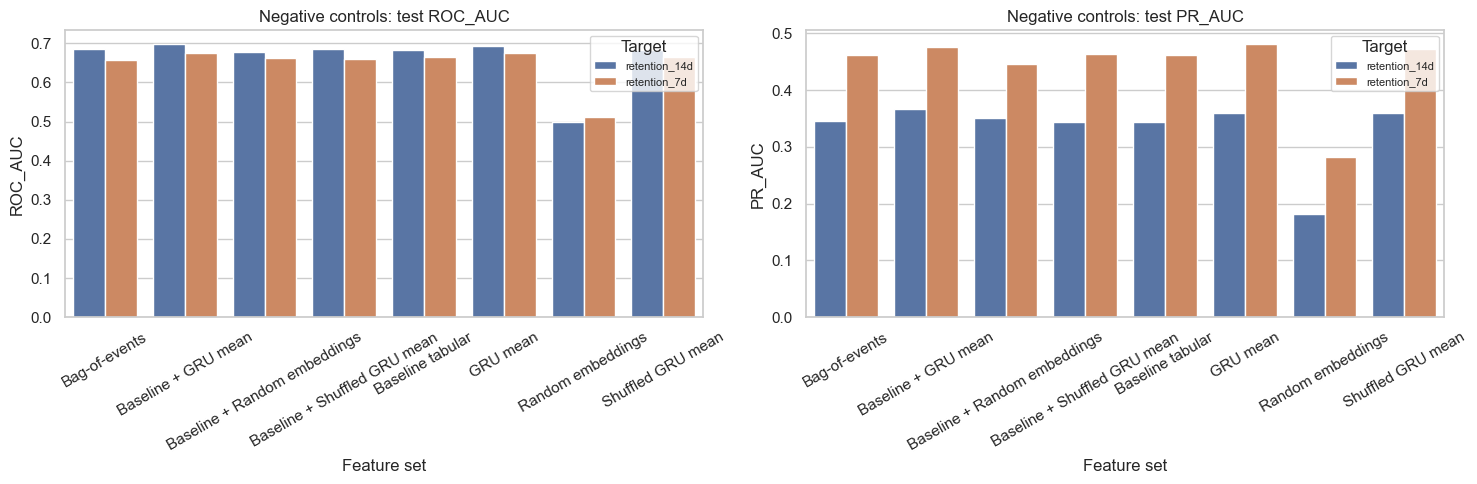

In [7]:
plot_pdf = to_pandas(test_metrics_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
for ax, metric_name in zip(axes, ['roc_auc', 'pr_auc']):
    sns.barplot(data=plot_pdf, x='feature_set', y=metric_name, hue='label', ax=ax)
    ax.set_title(f'Negative controls: test {metric_name.upper()}')
    ax.set_xlabel('Feature set')
    ax.set_ylabel(metric_name.upper())
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Target', fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'negative_controls_test_metrics.png', dpi=180)
plt.show()

## Итог

Negative controls дают три важных вывода.

Во-первых, `Random embeddings` не несут полезного сигнала: на `test` они дают ROC-AUC `0.5104` для `retention_7d` и `0.4982` для `retention_14d`. Это близко к случайному уровню и заметно ниже `GRU mean` (`0.6756` и `0.6937`). Значит, качество RNN-эмбеддингов не объясняется просто большой размерностью признаков.

Во-вторых, `Bag-of-events` оказывается конкурентным с табличными baseline-признаками, но слабее RNN-представлений. Для `retention_7d` он даёт ROC-AUC `0.6575` против `0.6639` у baseline и `0.6756` у `GRU mean`; для `retention_14d` — `0.6842` против `0.6830` у baseline и `0.6937` у `GRU mean`. Это показывает, что состав ранних событий сам по себе содержит заметный сигнал удержания.

В-третьих, `Shuffled GRU mean` сохраняет большую часть сигнала, но на `test` уступает обычному `GRU mean` по ROC-AUC: для `retention_7d` `0.6649` против `0.6756`, для `retention_14d` `0.6824` против `0.6937`. При этом PR-AUC на `retention_14d` почти совпадает (`0.3605` против `0.3604`), а на `retention_7d` ниже (`0.4724` против `0.4812`). Поэтому честный вывод такой: в текущей downstream-задаче RNN-эмбеддинг точно не случайный, но большая часть сигнала связана с составом и частотами событий в early prefix; порядок добавляет полезный, но не доминирующий вклад.

Комбинации с Baseline-комбинации подтверждают этот вывод. `Baseline + GRU mean` даёт `0.6751 / 0.4757` на `retention_7d` и `0.6979 / 0.3663` на `retention_14d`, тогда как `Baseline + Shuffled GRU mean` ниже на обеих задачах (`0.6610 / 0.4633` и `0.6843 / 0.3433`). После перехода на общий split контроль уже не обгоняет основной RNN-вариант, но остаётся достаточно сильным, чтобы не переутверждать роль строгого порядка событий.